# Cross-model self-recognition — Llama vs Qwen

**Question.** When a model judges *"which of these two texts did I write?"*, is it
recognizing its **own model** (Llama vs Qwen) or its **own persona** (the specific
system prompt it was under)? We separate the two.

Each trial pairs the evaluator's **self** text — generated by *(evaluator_model,
evaluator_persona)* — against one **foil** on the same task. The foil differs from
the evaluator along one or both axes (`foil_type`):

- **`diff_model_same_persona`** — other model, *same* persona → **model recognition**
  (e.g. Llama-neutral vs Qwen-neutral: can Llama pick its own?).
- **`same_model_diff_persona`** — same model, *different* persona → within-model
  persona recognition.
- **`diff_model_diff_persona`** — both differ → easiest.

Two conditions: **active** (evaluator persona induced as a system prompt) and
**neutral** (no system prompt — the baseline that isolates the active-state gain).
Text order and answer letter are counterbalanced, so **chance = 0.5** and raw
accuracy is position/letter-bias free. Rows are `PersonaCrossModelEvalRecord`
(see `core/schemas.py`), produced by `evaluate_cross_model.py`
(config: `self_recognition_cross_model`).

In [8]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "core").is_dir() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import logging; logging.basicConfig(level=logging.INFO)
import pandas as pd, matplotlib.pyplot as plt
import experiments.self_recognition.analyze_behavior_helpers as B      # stats + plotters
import experiments.self_recognition.analyze_cross_model_helpers as X   # cross-model load/agg
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)

EVAL_DIR = "cross_model_v1"                       # the config's eval_dir
MODELS = ["meta-llama/Llama-3.1-8B-Instruct", "Qwen/Qwen2.5-32B-Instruct"]
df = X.load_cross_model(EVAL_DIR, MODELS)
print(f"{len(df):,} trials | evaluators: {sorted(df.evaluator_slug.unique())}")
print("conditions:", df.condition.value_counts().to_dict())
print("foil types:", df.foil_type.value_counts().to_dict())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
60,048 trials | evaluators: ['Llama-3-1-8B-Instruct', 'Qwen2-5-32B-Instruct']
conditions: {'active': 30024, 'neutral': 30024}
foil types: {'same_model_diff_persona': 25920, 'diff_model_diff_persona': 25920, 'diff_model_same_persona': 8208}


## 0 · Balance check

Counterbalancing should make the correct answer ≈ 50% A and the self text ≈ 50%
first within every (evaluator, foil_type, condition) cell. If not, something is
wrong with enumeration.

In [9]:
bal = (df.assign(correctA=df.correct_answer.eq("A"), self1=df.text1_is_self)
         .groupby(["evaluator_slug","foil_type","condition"])
         .agg(frac_correct_A=("correctA","mean"), frac_self_first=("self1","mean"), n=("trial_id","size")))
display(bal.round(3))

frac_correct_A  frac_self_first     n
evaluator_slug        foil_type               condition                                       
Llama-3-1-8B-Instruct diff_model_diff_persona active                0.5              0.5  6480
                                              neutral               0.5              0.5  6480
                      diff_model_same_persona active                0.5              0.5  2052
                                              neutral               0.5              0.5  2052
                      same_model_diff_persona active                0.5              0.5  6480
                                              neutral               0.5              0.5  6480
Qwen2-5-32B-Instruct  diff_model_diff_persona active                0.5              0.5  6480
                                              neutral               0.5              0.5  6480
                      diff_model_same_persona active                0.5              0.5  2052
                                              neutral               0.5              0.5  2052
                      same_model_diff_persona active                0.5              0.5  6480
                                              neutral               0.5              0.5  6480

## 1 · Model recognition — can a model pick its own output from the other model's?

Restricted to **`diff_model_same_persona`** (foil = other model, *same* persona),
so the ONLY thing that differs between the two texts is which model wrote them.
Above 0.5 = the model can recognize its own model-level fingerprint. Compare
**active vs neutral**: if neutral is already high, the model-fingerprint is in the
text itself (doesn't need the persona active).

,evaluator_slug,condition,n,accuracy,ci_lo,ci_hi,p_vs_chance,mean_prob_correct
0,Llama-3-1-8B-Instruct,active,2052,0.576998,0.555498,0.598210,3.555822e-12,0.553290
1,Llama-3-1-8B-Instruct,neutral,2052,0.561891,0.540328,0.583223,2.335504e-08,0.538110
2,Qwen2-5-32B-Instruct,active,2052,0.456140,0.434692,0.477753,7.765588e-05,0.455733
3,Qwen2-5-32B-Instruct,neutral,2052,0.484893,0.463317,0.506525,1.781065e-01,0.490973


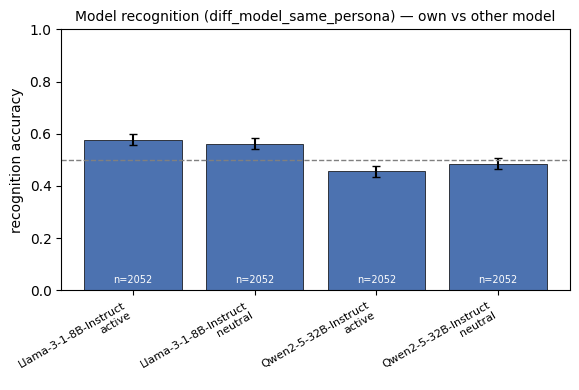

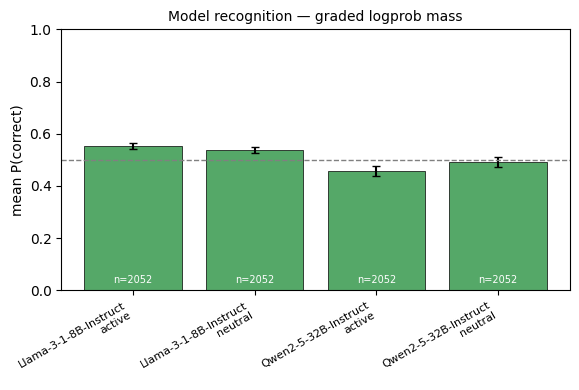

In [10]:
mr = X.model_recognition(df, by=("evaluator_slug","condition"))
mr["label"] = mr.evaluator_slug + "\n" + mr.condition
display(mr[["evaluator_slug","condition","n","accuracy","ci_lo","ci_hi","p_vs_chance","mean_prob_correct"]])
B.plot_accuracy(mr, title="Model recognition (diff_model_same_persona) — own vs other model")
plt.show()
B.plot_accuracy(mr, value="mean_prob_correct", lo_col="prob_ci_lo", hi_col="prob_ci_hi",
                ylabel="mean P(correct)", color="#55A868",
                title="Model recognition — graded logprob mass")
plt.show()

### 1b · Model recognition on the NEUTRAL persona specifically

Your first question: *can Llama and Qwen recognize their own **neutral** texts from
the other model?* This is model recognition with `evaluator_persona = default_neutral`
(no persona style to lean on — pure model fingerprint).

,evaluator_slug,condition,n,accuracy,ci_lo,ci_hi,p_vs_chance,mean_prob_correct
0,Llama-3-1-8B-Instruct,active,76,0.473684,0.365421,0.584480,0.730753,0.510997
1,Llama-3-1-8B-Instruct,neutral,76,0.618421,0.506018,0.719429,0.051172,0.535616
2,Qwen2-5-32B-Instruct,active,76,0.500000,0.390326,0.609674,1.000000,0.501285
3,Qwen2-5-32B-Instruct,neutral,76,0.486842,0.377837,0.597113,0.908677,0.488057


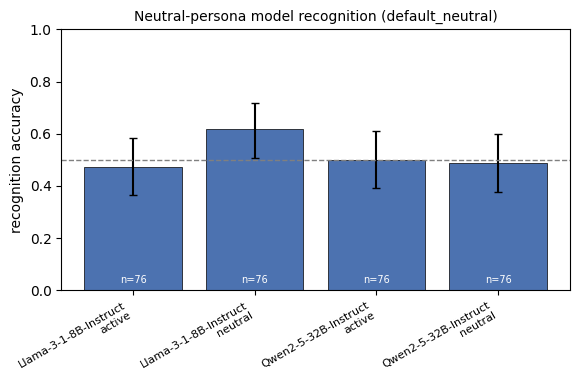

In [11]:
NEUTRAL_PERSONA = "default_neutral"   # adjust if your neutral persona is named differently
sub = df[(df.foil_type=="diff_model_same_persona") & (df.evaluator_persona==NEUTRAL_PERSONA)]
if sub.empty:
    print(f"no rows for evaluator_persona={NEUTRAL_PERSONA!r}; personas present:",
          sorted(df.evaluator_persona.unique()))
else:
    nt = X.agg(sub, by=["evaluator_slug","condition"])
    nt["label"] = nt.evaluator_slug + "\n" + nt.condition
    display(nt[["evaluator_slug","condition","n","accuracy","ci_lo","ci_hi","p_vs_chance","mean_prob_correct"]])
    B.plot_accuracy(nt, title=f"Neutral-persona model recognition ({NEUTRAL_PERSONA})")
    plt.show()

## 2 · Foil-type ladder — model cue vs persona cue

For the **active** persona, how hard is each foil to reject? Read within an
evaluator model:

- **other model, same persona** — only the model differs. High here = strong
  *model* self-recognition.
- **same model, other persona** — only the persona differs. High here = strong
  *persona* self-recognition.
- **other model, other persona** — both differ (should be easiest).

The contrast between the first two tells you whether the model's "self" is
anchored more to its **model identity** or its **persona identity**.

,evaluator_slug,foil_type,n,accuracy,ci_lo,ci_hi,p_vs_chance,mean_prob_correct
0,Llama-3-1-8B-Instruct,diff_model_diff_persona,6480,0.679012,0.667542,0.690270,0.000000e+00,0.627728
1,Llama-3-1-8B-Instruct,diff_model_same_persona,2052,0.576998,0.555498,0.598210,3.555822e-12,0.553290
2,Llama-3-1-8B-Instruct,same_model_diff_persona,6480,0.646142,0.634416,0.657695,0.000000e+00,0.601786
3,Qwen2-5-32B-Instruct,diff_model_diff_persona,6480,0.700772,0.689506,0.711799,0.000000e+00,0.693855
4,Qwen2-5-32B-Instruct,diff_model_same_persona,2052,0.456140,0.434692,0.477753,7.765588e-05,0.455733
5,Qwen2-5-32B-Instruct,same_model_diff_persona,6480,0.713272,0.702137,0.724154,0.000000e+00,0.702783


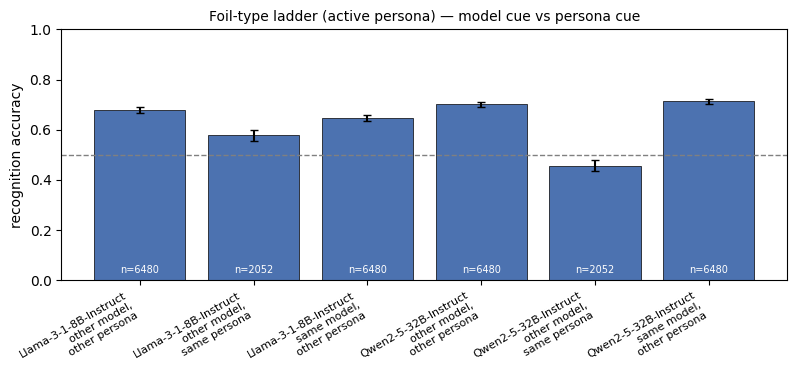

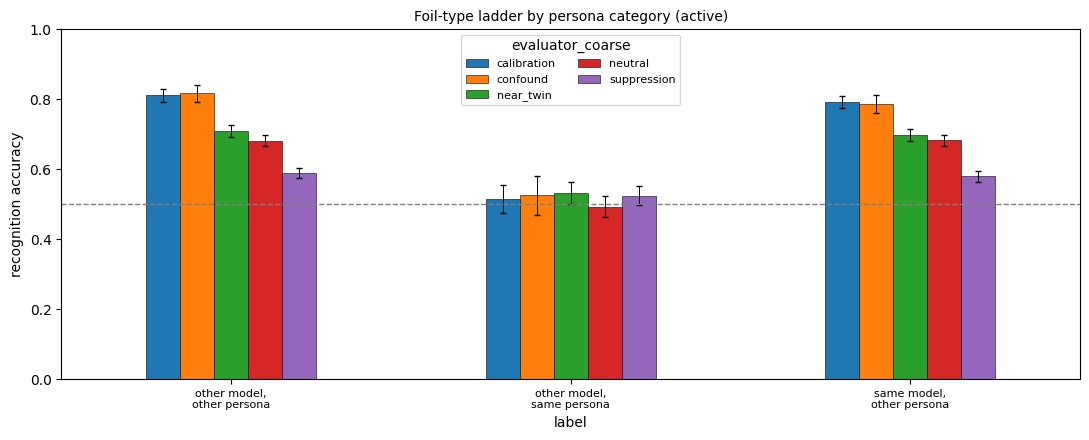

In [12]:
ladder = X.foil_type_ladder(df, condition="active", by_model=True)
display(ladder[["evaluator_slug","foil_type","n","accuracy","ci_lo","ci_hi","p_vs_chance","mean_prob_correct"]])
B.plot_accuracy(ladder, title="Foil-type ladder (active persona) — model cue vs persona cue")
plt.show()

# By-category view: split each foil_type by the evaluator persona's category.
lc = X.agg(df[df.condition=="active"], by=["foil_label","evaluator_coarse"])
lc = lc.rename(columns={"foil_label":"label"})
if not lc.empty:
    B.plot_contrast_by_category(lc, title="Foil-type ladder by persona category (active)")
    plt.show()

## 3 · Active vs neutral surplus (the active-state gain)

Cross-model analogue of case7 − case10: how much does *inducing the persona* add
over the no-persona baseline, per foil_type? A positive surplus means being the
persona helps recognition beyond whatever is readable from the text alone.

In [13]:
for ft in ["diff_model_same_persona","same_model_diff_persona","diff_model_diff_persona"]:
    s = X.active_vs_neutral(df, foil_type=ft, by=("evaluator_slug",))
    print(f"\n=== {ft} ===")
    display(s.round(3))


=== diff_model_same_persona ===


,evaluator_slug,acc_active,prob_active,n,acc_neutral,prob_neutral,acc_surplus,prob_surplus
0,Llama-3-1-8B-Instruct,0.577,0.553,2052,0.562,0.538,0.015,0.015
1,Qwen2-5-32B-Instruct,0.456,0.456,2052,0.485,0.491,-0.029,-0.035



=== same_model_diff_persona ===


,evaluator_slug,acc_active,prob_active,n,acc_neutral,prob_neutral,acc_surplus,prob_surplus
0,Llama-3-1-8B-Instruct,0.646,0.602,6480,0.497,0.498,0.149,0.104
1,Qwen2-5-32B-Instruct,0.713,0.703,6480,0.504,0.500,0.209,0.203



=== diff_model_diff_persona ===


,evaluator_slug,acc_active,prob_active,n,acc_neutral,prob_neutral,acc_surplus,prob_surplus
0,Llama-3-1-8B-Instruct,0.679,0.628,6480,0.546,0.533,0.133,0.095
1,Qwen2-5-32B-Instruct,0.701,0.694,6480,0.476,0.481,0.225,0.213


## 4 · Per-persona grid (evaluator model × persona)

Accuracy for the **model-recognition** foil (other model, same persona), active
condition, per persona and evaluator. Personas whose *style* is model-invariant
should still be recognizable here only via the model fingerprint — a clean look at
where model self-recognition is strong or absent.

In [14]:
grid = X.agg(df[(df.foil_type=="diff_model_same_persona") & (df.condition=="active")],
             by=["evaluator_slug","evaluator_persona"])
if not grid.empty:
    piv = grid.pivot_table(index="evaluator_persona", columns="evaluator_slug",
                           values="accuracy", observed=True).round(3)
    display(piv)

evaluator_slug,Llama-3-1-8B-Instruct,Qwen2-5-32B-Instruct
evaluator_persona,,
archaic_speaker,0.434,0.724
architect,0.526,0.276
astronomer,0.579,0.447
botanist,0.618,0.329
child_five,0.632,0.211
conservative,0.632,0.526
contrarian_suppressed,0.605,0.566
cube_suppressed,0.605,0.408
default_neutral,0.474,0.500
